<a href="https://colab.research.google.com/github/AKookani/Qiskit_course/blob/Main/Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Circuit Assignment

## Reminder
This week's assignment is a continuation of the previous one. The quantum circuit you are asked to implement is similar to last week's task, so some of the steps will feel repetitive. However, this time, you'll focus on analyzing the circuit's state by obtaining the density matrix, visualizing the Bloch sphere, and calculating the output counts for specific qubits.

## Task
1. **Build the Quantum Circuit:** Recreate the quantum circuit shown in the image below. Ensure that all gates and operations are applied correctly.

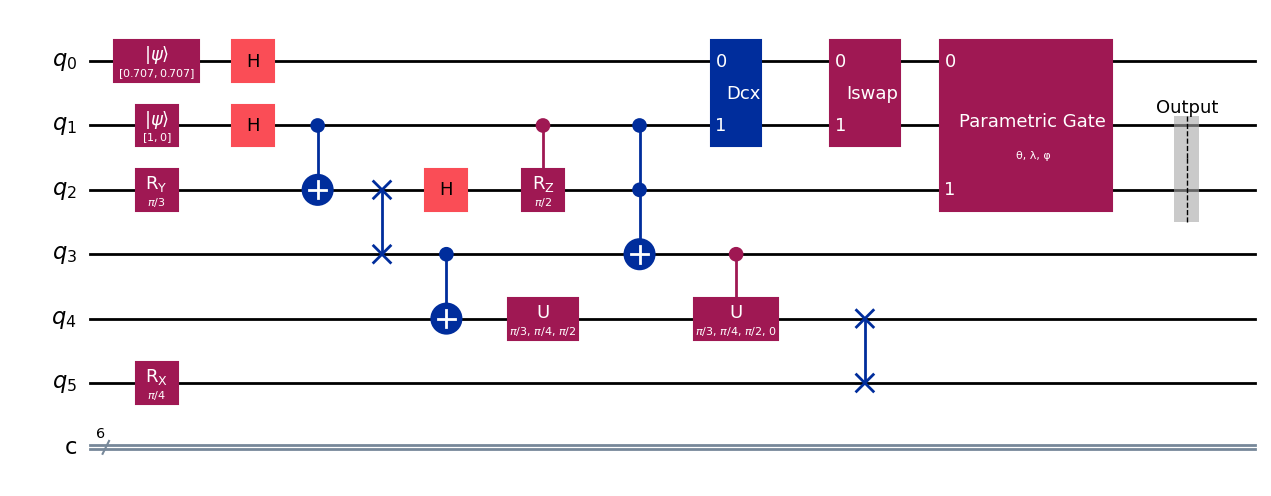
   
2. **Parametric Gate:**
   - Assign the following values to the parameters of the parametric gate:
     - θ = π/2
     - ϕ = π/4
     - λ = π/8

3. **Obtain the Density Matrix:**
   - Use the following code to obtain the density matrix of the entire circuit:
     ```python
     from qiskit.quantum_info import DensityMatrix
     density_matrix = DensityMatrix.from_instruction(qc)
     ```

4. **Partial Trace:**
   - After obtaining the complete density matrix, use the partial trace to isolate the desired qubits (qubits 1 and 2):
     ```python
     from qiskit.quantum_info import partial_trace
     reduced_density_matrix = partial_trace(density_matrix, [excessive_qubits])
     ```

5. **Visualize Results:**
   - **Density Matrix:** Display the density matrix in LaTeX form using the following command:
     ```python
     reduced_density_matrix.draw('latex')
     ```

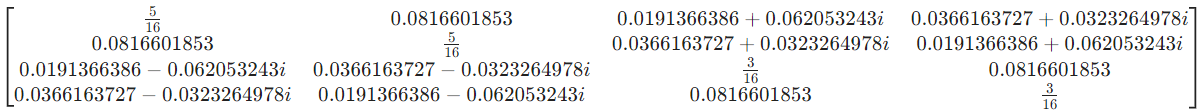


   - **Bloch Sphere:** Visualize the state on the Bloch sphere using:
     ```python
     reduced_density_matrix.draw('bloch')
     ```

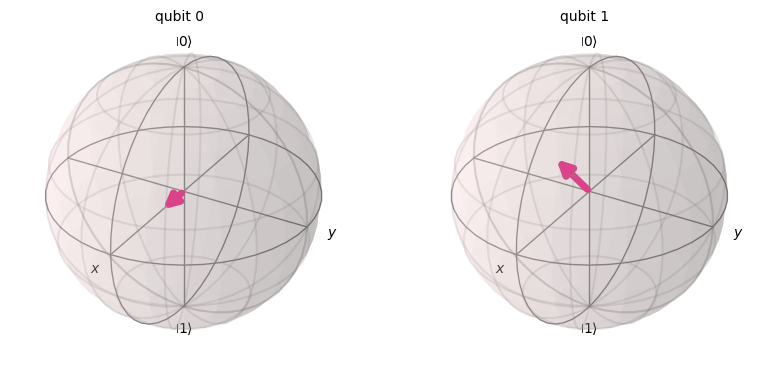

   - **Counts:** Simulate the measurement of the circuit and plot the counts for the output states of qubits 1 and 2:
     ```python
     from qiskit.visualization import plot_histogram
     counts = density_matrix.sample_counts(shots=1024)
     plot_histogram(counts)
     ```

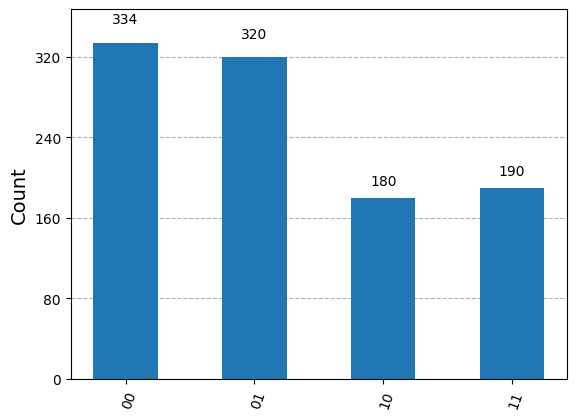

### Hint:
- Be careful when selecting the qubits for the partial trace function. Any qubits that are not qubits 1 or 2 should be passed as the list of `excessive_qubits`.
- Remember that this is an opportunity to deepen your understanding of quantum states and operations.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.5/108.5 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136816 sha256=ba2dd3cff0aff3619506aa93282d096225551d25c899be462a515dc5c953653a
  Stored in directory: /root/.cache/pip/wheels/d3/31/8b/e09b0386afd80cfc556c00408c9aeea5c35c4d484a9c762fd5
Successfully built pylatexenc


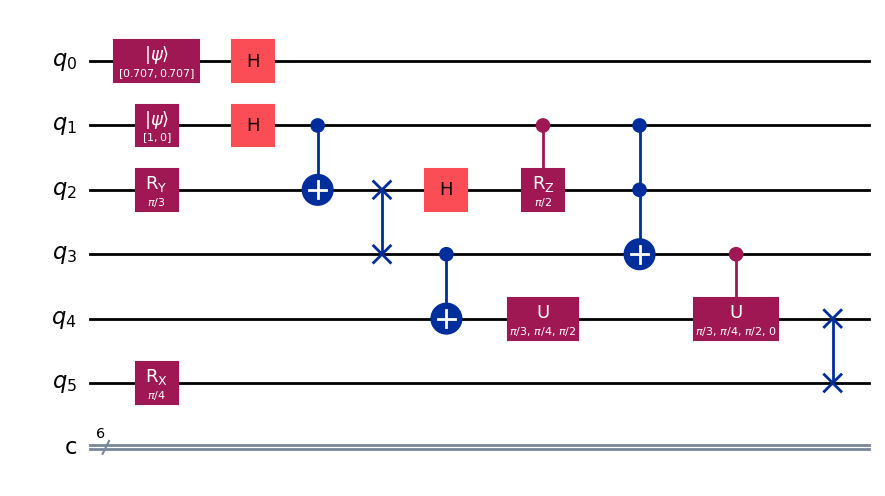

In [1]:
# Solution:

!pip install qiskit ipywidgets
!pip install pylatexenc

import math
from qiskit import QuantumCircuit

# Initialize a quantum circuit with 6 qubits and 6 classical bits
qc = QuantumCircuit(6, 6)

# Initialize qubits
qc.initialize([1/2**0.5, 1/2**0.5], 0)  # |+⟩ state
qc.initialize([1, 0], 1)  # |0⟩ state

qc.h(0)
qc.h(1)
qc.ry(math.pi/3, 2)
qc.cx(1, 2)
qc.swap(2, 3)
qc.rx(math.pi/4, 5)
qc.cx(3, 4)

# Apply gates according to the circuit description
qc.h(2)
qc.crz(math.pi/2, 1, 2)

# Multi-Controlled NOT (Toffoli)
qc.ccx(1, 2, 3)

# Apply U gate on qubit 4
qc.u(math.pi/3, math.pi/4, math.pi/2, 4)

# Apply Controlled-U gate (control on qubit 3, target on qubit 4)
qc.cu(math.pi/3, math.pi/4, math.pi/2, 0, 3, 4)

# Swap gate between qubits 4 and 5
qc.swap(4, 5)

# Measure all qubits
#qc.measure([0, 1, 2, 3, 4, 5], [0, 1, 2, 3, 4, 5])
qc.draw('mpl')

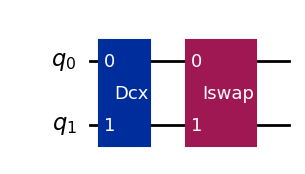

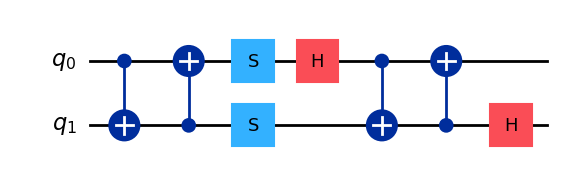

In [2]:
qc2 = QuantumCircuit(2)
qc2.dcx(0,1)
qc2.iswap(0,1)
display(qc2.draw('mpl'))
qc2.decompose().draw('mpl')

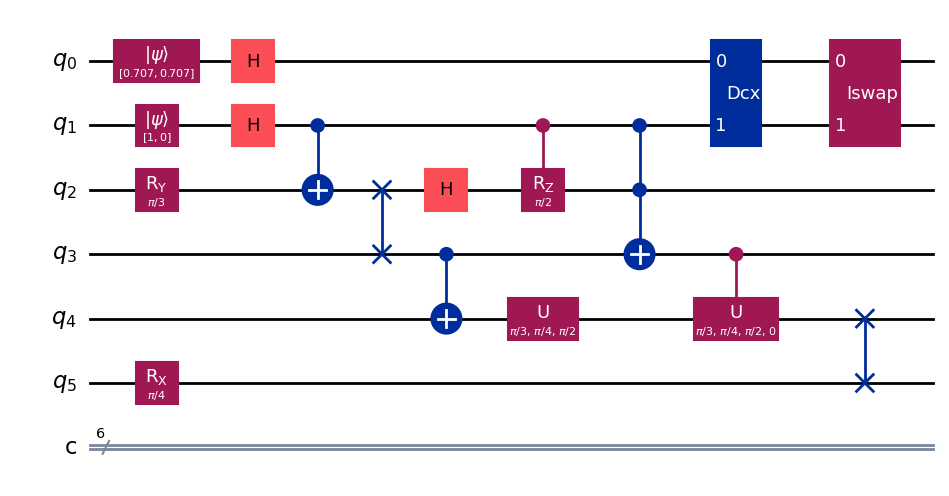

In [3]:
qc_combined = qc.compose(qc2, qubits=[0, 1])
qc_combined.draw('mpl')

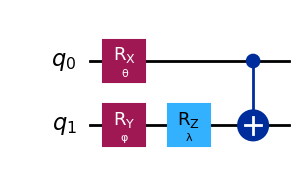

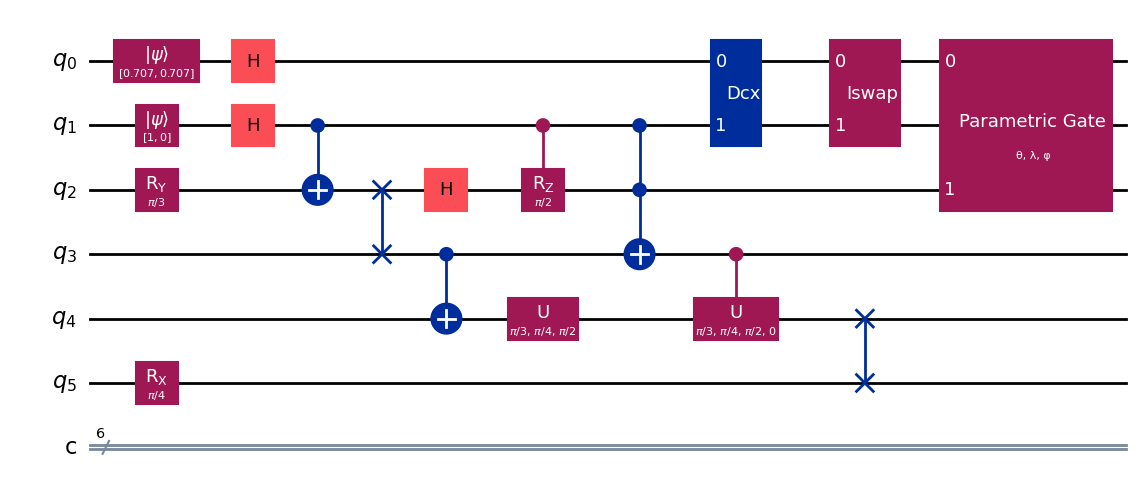

In [4]:
from qiskit.circuit import Parameter

# Define the parameters for the parametric circuit
theta = Parameter('θ')
phi = Parameter('φ')
lam = Parameter('λ')

# Create a new 2-qubit parametric quantum circuit
param_qc = QuantumCircuit(2)

# Qubit 0: Apply Rx(θ)
param_qc.rx(theta, 0)

# Qubit 1: Apply Ry(φ) and Rz(λ)
param_qc.ry(phi, 1)
param_qc.rz(lam, 1)

# Apply a CNOT with control on qubit 0 and target on qubit 1
param_qc.cx(0, 1)

# Convert the parametric circuit to a custom gate
param_gate = param_qc.to_gate(label="Parametric Gate")

# Print the parametric circuit for clarity
display(param_qc.draw('mpl'))

# Assume the circuit from Part 2 is called 'qc2'
# Append the custom gate to qubits 0 and 2 of qc2
qc_combined.append(param_gate, [0, 2])

# Draw the full circuit
qc_combined.draw('mpl')

In [5]:
from math import pi

qcf = qc_combined.assign_parameters({theta: pi/2,
                               phi: pi/4,
                               lam: pi/8})

<IPython.core.display.Latex object>

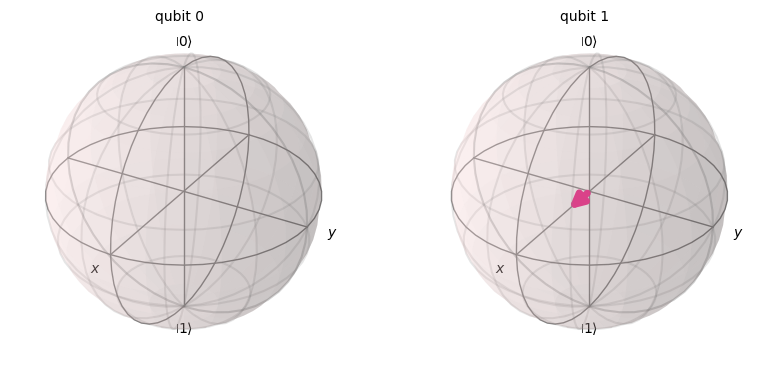

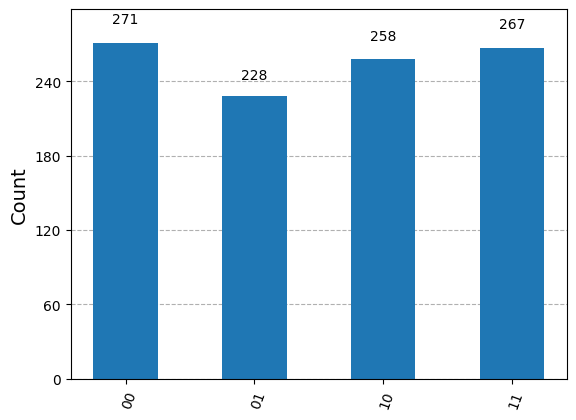

In [6]:
from qiskit.quantum_info import DensityMatrix, partial_trace
from qiskit.visualization import plot_histogram

rho = DensityMatrix.from_instruction(qcf)
rho1 = partial_trace(rho, [0, 3, 4, 5])
display(rho1.draw('latex'))

display(rho1.draw('bloch'))
counts = rho1.sample_counts(shots=1024)
display(plot_histogram(counts))